In [ ]:
import pandas as pd
import numpy as np


#NLTK libraries
import nltk
import re
import string
from wordcloud import WordCloud,STOPWORDS
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn import svm, datasets
from sklearn import preprocessing

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from textblob import TextBlob
from plotly import tools
import plotly.graph_objs as go
from plotly.offline import iplot
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


from scipy.interpolate import interp1d
from itertools import cycle
import cufflinks as cf
from collections import defaultdict
from collections import Counter
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('/content/convertcsv.csv')

In [ ]:
df.head()

,reviewerID,asin,reviewerName,helpful/0,helpful/1,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",0,0,"Not much to write about here, but it does exac...",5,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,13,14,The product does exactly as it should and is q...,5,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",1,1,The primary job of this device is to block the...,5,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",0,0,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,0,0,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1392940800,"02 21, 2014"


In [ ]:
df.tail(10)

,reviewerID,asin,reviewerName,helpful/0,helpful/1,reviewText,overall,summary,unixReviewTime,reviewTime
10251,A3M1PLEYNDEYO8,B00JBIVXGC,"G. Thomas ""Tom""",0,0,True to phosphor bronze these strings have a m...,5,"they sound great, feel great",1404172800,"07 1, 2014"
10252,A1SD1C8XK3Z3V1,B00JBIVXGC,"guitfiddleblue ""guitfiddleblue""",0,0,I've used Elixirs for about five years now. Th...,5,Elixirs just sound good,1404086400,"06 30, 2014"
10253,A2VRAT69JDAD3W,B00JBIVXGC,"Jason Whitt ""Whittmeister""",0,0,"I'm a D'Addario man myself, but hey free is fr...",4,"I'm a D'Addario man myself, but hey free is ...",1405900800,"07 21, 2014"
10254,A306NASGVUDFKF,B00JBIVXGC,"Jeffrey E ""jeffinaustintx""",0,0,I really like these strings. While they are n...,5,I really like these strings,1404432000,"07 4, 2014"
10255,A1TSKKBNV38E8Y,B00JBIVXGC,"K. Harriger ""K.R. Harriger""",0,0,I have lots of friends who play these strings....,3,"Hmmm.... I like them, but with a lot of reserv...",1403654400,"06 25, 2014"
10256,A14B2YH83ZXMPP,B00JBIVXGC,Lonnie M. Adams,0,0,"Great, just as expected. Thank to all.",5,Five Stars,1405814400,"07 20, 2014"
10257,A1RPTVW5VEOSI,B00JBIVXGC,Michael J. Edelman,0,0,I've been thinking about trying the Nanoweb st...,5,"Long life, and for some players, a good econom...",1404259200,"07 2, 2014"
10258,AWCJ12KBO5VII,B00JBIVXGC,Michael L. Knapp,0,0,I have tried coated strings in the past ( incl...,4,Good for coated.,1405987200,"07 22, 2014"
10259,A2Z7S8B5U4PAKJ,B00JBIVXGC,"Rick Langdon ""Scriptor""",0,0,"Well, MADE by Elixir and DEVELOPED with Taylor...",4,Taylor Made,1404172800,"07 1, 2014"
10260,A2WA8TDCTGUADI,B00JBIVXGC,TheTerrorBeyond,0,0,"These strings are really quite good, but I wou...",4,"These strings are really quite good, but I wou...",1405468800,"07 16, 2014"


In [ ]:
df.shape

(10261, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviewerID      10261 non-null  object
 1   asin            10261 non-null  object
 2   reviewerName    10234 non-null  object
 3   helpful/0       10261 non-null  int64 
 4   helpful/1       10261 non-null  int64 
 5   reviewText      10254 non-null  object
 6   overall         10261 non-null  int64 
 7   summary         10261 non-null  object
 8   unixReviewTime  10261 non-null  int64 
 9   reviewTime      10261 non-null  object
dtypes: int64(4), object(6)
memory usage: 801.8+ KB


In [ ]:
df.isnull().sum()

,0
reviewerID,0
asin,0
reviewerName,27
helpful/0,0
helpful/1,0
reviewText,7
overall,0
summary,0
unixReviewTime,0
reviewTime,0


In [ ]:
df['reviewText']=df['reviewText'].fillna('Missing')# fill any nan value with word Missing

df.isnull().sum()

,0
reviewerID,0
asin,0
reviewerName,27
helpful/0,0
helpful/1,0
reviewText,0
overall,0
summary,0
unixReviewTime,0
reviewTime,0


In [ ]:
df['reviews']=df['reviewText']+df['summary'] # merge reviewtext and summey  to make data more organized
df=df.drop(['reviewText', 'summary'], axis=1)
df.head()

,reviewerID,asin,reviewerName,helpful/0,helpful/1,overall,unixReviewTime,reviewTime,reviews
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",0,0,5,1393545600,"02 28, 2014","Not much to write about here, but it does exac..."
1,A14VAT5EAX3D9S,1384719342,Jake,13,14,5,1363392000,"03 16, 2013",The product does exactly as it should and is q...
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",1,1,5,1377648000,"08 28, 2013",The primary job of this device is to block the...
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",0,0,5,1392336000,"02 14, 2014",Nice windscreen protects my MXL mic and preven...
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,0,0,5,1392940800,"02 21, 2014",This pop filter is great. It looks and perform...


In [ ]:
if 'helpful/0' in df.columns and 'helpful/1' in df.columns:
    df['helpful'] = df[['helpful/0' ,  'helpful/1']].values.tolist()
    df = df.drop(['helpful/0', 'helpful/1'], axis=1)
display(df.head())


,reviewerID,asin,reviewerName,overall,unixReviewTime,reviewTime,reviews,helpful
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",5,1393545600,"02 28, 2014","Not much to write about here, but it does exac...","[0, 0]"
1,A14VAT5EAX3D9S,1384719342,Jake,5,1363392000,"03 16, 2013",The product does exactly as it should and is q...,"[13, 14]"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",5,1377648000,"08 28, 2013",The primary job of this device is to block the...,"[1, 1]"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",5,1392336000,"02 14, 2014",Nice windscreen protects my MXL mic and preven...,"[0, 0]"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,5,1392940800,"02 21, 2014",This pop filter is great. It looks and perform...,"[0, 0]"


In [ ]:
df['overall'].value_counts() # indication that data unbalanced

,count
overall,
5,6938
4,2084
3,772
2,250
1,217


In [ ]:
def f(row):

    #This function returns sentiment value based on the overall ratings from the user

    if row['overall'] == 3.0:
        val = 'Neutral'
    elif row['overall'] == 1.0 or row['overall'] == 2.0:
        val = 'Negative'
    elif row['overall'] == 4.0 or row['overall'] == 5.0:
        val = 'Positive'
    else:
        val = -1
    return val

In [ ]:
df['sentiment'] = df.apply(f,axis=1)
df.head()

,reviewerID,asin,reviewerName,overall,unixReviewTime,reviewTime,reviews,helpful,sentiment
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",5,1393545600,"02 28, 2014","Not much to write about here, but it does exac...","[0, 0]",Positive
1,A14VAT5EAX3D9S,1384719342,Jake,5,1363392000,"03 16, 2013",The product does exactly as it should and is q...,"[13, 14]",Positive
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",5,1377648000,"08 28, 2013",The primary job of this device is to block the...,"[1, 1]",Positive
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",5,1392336000,"02 14, 2014",Nice windscreen protects my MXL mic and preven...,"[0, 0]",Positive
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,5,1392940800,"02 21, 2014",This pop filter is great. It looks and perform...,"[0, 0]",Positive


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,9022
Neutral,772
Negative,467


In [ ]:
# new data frame which has date and year
new = df["reviewTime"].str.split(",", n = 1, expand = True)

# making separate date column from new data frame
df["date"]= new[0]

# making separate year column from new data frame
df["year"]= new[1]

df=df.drop(['reviewTime'], axis=1)
df.head()

,reviewerID,asin,reviewerName,overall,unixReviewTime,reviews,helpful,sentiment,date,year
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",5,1393545600,"Not much to write about here, but it does exac...","[0, 0]",Positive,02 28,2014
1,A14VAT5EAX3D9S,1384719342,Jake,5,1363392000,The product does exactly as it should and is q...,"[13, 14]",Positive,03 16,2013
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",5,1377648000,The primary job of this device is to block the...,"[1, 1]",Positive,08 28,2013
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",5,1392336000,Nice windscreen protects my MXL mic and preven...,"[0, 0]",Positive,02 14,2014
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,5,1392940800,This pop filter is great. It looks and perform...,"[0, 0]",Positive,02 21,2014


In [ ]:
# Splitting the date
new1 = df["date"].str.split(" ", n = 1, expand = True)

# adding month to the main dataset
df["month"]= new1[0]

# adding day to the main dataset
df["day"]= new1[1]

df=df.drop(['date'], axis=1)
df.head()

,reviewerID,asin,reviewerName,overall,unixReviewTime,reviews,helpful,sentiment,year,month,day
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",5,1393545600,"Not much to write about here, but it does exac...","[0, 0]",Positive,2014,02,28
1,A14VAT5EAX3D9S,1384719342,Jake,5,1363392000,The product does exactly as it should and is q...,"[13, 14]",Positive,2013,03,16
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",5,1377648000,The primary job of this device is to block the...,"[1, 1]",Positive,2013,08,28
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",5,1392336000,Nice windscreen protects my MXL mic and preven...,"[0, 0]",Positive,2014,02,14
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,5,1392940800,This pop filter is great. It looks and perform...,"[0, 0]",Positive,2014,02,21


Text(0, 0.5, 'Reviews count')

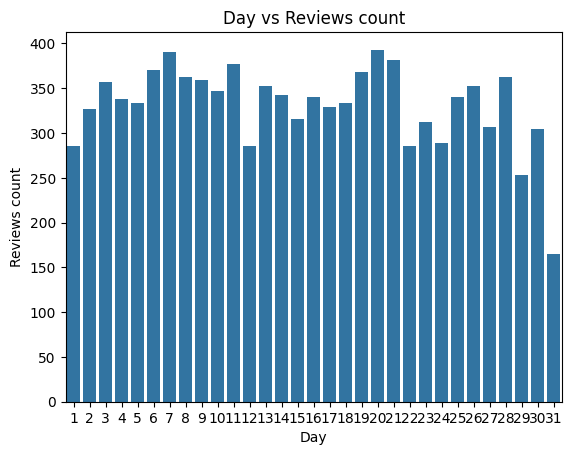

In [ ]:
#Creating a dataframe
day=pd.DataFrame(df.groupby('day')['reviews'].count()).reset_index()
day['day']=day['day'].astype('int64')
day.sort_values(by=['day'])

#Plotting the graph
sns.barplot(x="day", y="reviews", data=day)
plt.title('Day vs Reviews count')
plt.xlabel('Day')
plt.ylabel('Reviews count')

In [ ]:
# Calculate helpfulness rate from the list [helpful/0, helpful/1]
def calculate_helpful_rate(helpful_list):
    if helpful_list[0] == 0:
        return 0
    else:
        return round(helpful_list[0] / helpful_list[1], 2)

df['helpful_rate'] = df['helpful'].apply(calculate_helpful_rate)

# dropping the helpful column from main dataframe
# Check if 'helpful' column exists before dropping
if 'helpful' in df.columns:
    df = df.drop(['helpful'], axis=1)

display(df.head())

,reviewerID,asin,reviewerName,overall,unixReviewTime,reviews,sentiment,year,month,day,helpful_rate
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...",5,1393545600,"Not much to write about here, but it does exac...",Positive,2014,02,28,0.00
1,A14VAT5EAX3D9S,1384719342,Jake,5,1363392000,The product does exactly as it should and is q...,Positive,2013,03,16,0.93
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""",5,1377648000,The primary job of this device is to block the...,Positive,2013,08,28,1.00
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""",5,1392336000,Nice windscreen protects my MXL mic and preven...,Positive,2014,02,14,0.00
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,5,1392940800,This pop filter is great. It looks and perform...,Positive,2014,02,21,0.00


In [ ]:
df['helpful_rate'].value_counts()

,count
helpful_rate,
0.00,7215
1.00,2040
0.50,266
0.67,136
0.75,111
...,...
0.56,1
0.15,1
0.13,1


In [ ]:
df=df.drop(['reviewerName','unixReviewTime'], axis=1)

clean_reviews=df.copy()

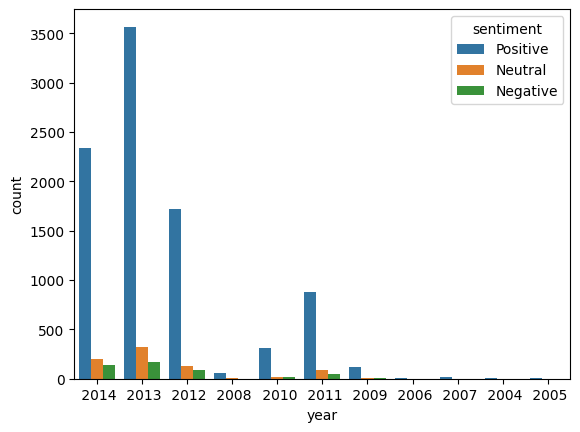

In [ ]:
sns.countplot(x='year', hue='sentiment', data=df)
plt.show()

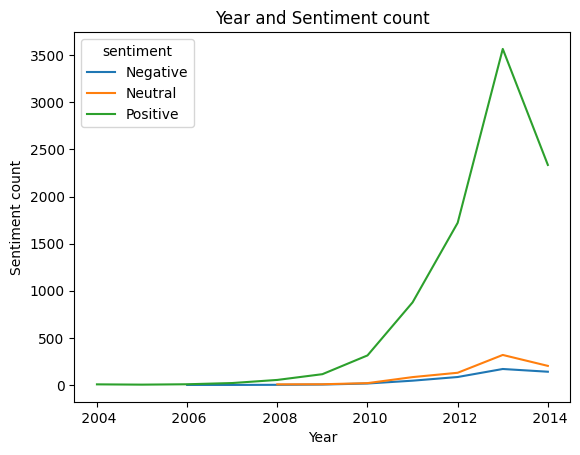

In [ ]:
df.groupby(['year','sentiment'])['sentiment'].count().unstack().plot(legend=True)
plt.title('Year and Sentiment count')
plt.xlabel('Year')
plt.ylabel('Sentiment count')
plt.show()
#       positive  negative
#year
#2020      120        80   <-- unstack
#2021      150        90

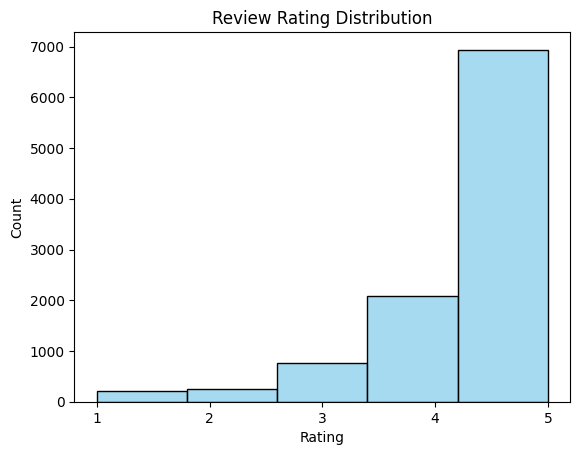

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the 'overall' ratings histogram
sns.histplot(df['overall'], bins=5, kde=False, color='skyblue', edgecolor='black')

# Adding plot details
plt.title('Review Rating Distribution')
plt.xticks([1, 2, 3, 4, 5])  # Set the x-axis ticks to only show integer values
plt.xlabel('Rating')
plt.ylabel('Count')

# Display the plot
plt.show()

In [ ]:
import re
def review_cleaning(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub('\[.*?\]', '', text) # Remove text in square brackets
    text = re.sub('https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub('<.*?>+', '', text) # Remove HTML tags
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub('\n', '', text)  # Remove newlines
    text = re.sub('\w*\d\w*', '', text)   # Remove words with numbers
    return text



In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])

df['clean_text'] = df['reviews'].apply(review_cleaning)
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# df['reviews'] = df['reviews'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))
df.head()

,reviewerID,asin,overall,reviews,sentiment,year,month,day,helpful_rate,clean_text
0,A2IBPI20UZIR0U,1384719342,5,"Not much to write about here, but it does exac...",Positive,2014,02,28,0.00,much write exactly supposed filters pop sounds...
1,A14VAT5EAX3D9S,1384719342,5,The product does exactly as it should and is q...,Positive,2013,03,16,0.93,product exactly quite affordablei realized dou...
2,A195EZSQDW3E21,1384719342,5,The primary job of this device is to block the...,Positive,2013,08,28,1.00,primary job device block breath would otherwis...
3,A2C00NNG1ZQQG2,1384719342,5,Nice windscreen protects my MXL mic and preven...,Positive,2014,02,14,0.00,nice windscreen protects mxl mic prevents pops...
4,A94QU4C90B1AX,1384719342,5,This pop filter is great. It looks and perform...,Positive,2014,02,21,0.00,pop filter great looks performs like studio fi...


In [ ]:
df = df.drop('reviews', axis=1)
df.head()

,reviewerID,asin,overall,sentiment,year,month,day,helpful_rate,clean_text
0,A2IBPI20UZIR0U,1384719342,5,Positive,2014,02,28,0.00,much write exactly supposed filters pop sounds...
1,A14VAT5EAX3D9S,1384719342,5,Positive,2013,03,16,0.93,product exactly quite affordablei realized dou...
2,A195EZSQDW3E21,1384719342,5,Positive,2013,08,28,1.00,primary job device block breath would otherwis...
3,A2C00NNG1ZQQG2,1384719342,5,Positive,2014,02,14,0.00,nice windscreen protects mxl mic prevents pops...
4,A94QU4C90B1AX,1384719342,5,Positive,2014,02,21,0.00,pop filter great looks performs like studio fi...


Stemming the reviews

Stemming is a method of deriving root word from the inflected word. Here we extract the clean_text and convert the words in reviews to its root word. for example,

Going->go
Finally->fina


If you notice, the root words doesn't need to carry a semantic meaning. There is another technique knows as Lemmatization where it converts the words into root words which has a semantic meaning. Simce it takes time.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# calling the label encoder function
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'sentiment'.
df['sentiment']= label_encoder.fit_transform(df['sentiment'])

df['sentiment'].unique()

array([2, 1, 0])

In [ ]:
review_features=df.copy()
review_features = review_features[['clean_text']].reset_index(drop=True)
review_features.head()

,clean_text
0,much write exactly supposed filters pop sounds...
1,product exactly quite affordablei realized dou...
2,primary job device block breath would otherwis...
3,nice windscreen protects mxl mic prevents pops...
4,pop filter great looks performs like studio fi...


In [ ]:
from nltk.stem.porter import PorterStemmer

#Performing stemming on the review dataframe
ps = PorterStemmer()

#splitting and adding the stemmed words except stopwords
corpus = []
for i in range(0, len(review_features)):
    review = re.sub('[^a-zA-Z]', ' ', review_features['clean_text'][i])
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stop_words]
    review = ' '.join(review)
    corpus.append(review)

In [ ]:
corpus[9]


'monster make best cabl lifetim warranti doesnt hurt either isnt top line seri work great bass guitar rig time cant go wrong monster cablesbest instrument cabl market'

TFIDF(Term Frequency — Inverse Document Frequency)


TF-IDF stands for “Term Frequency — Inverse Document Frequency”. This is a technique to quantify a word in documents, we generally compute a weight to each word which signifies the importance of the word in the document and corpus. This method is a widely used technique in Information Retrieval and Text Mining.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
# TF-IDF feature matrix
X= tfidf_vectorizer.fit_transform(review_features['clean_text'])
X.shape

(10261, 5000)

In [ ]:
y=df['sentiment']

Handling Imbalance target feature-SMOTE


In our target feature, we noticed that we got a lot of positive sentiments compared to negative and neutral. So it is crucial to balanced the classes in such situations. Here I have used SMOTE(Synthetic Minority Oversampling Technique) to balance out the imbalanced dataset problem.It aims to balance class distribution by randomly increasing minority class examples by replicating them.

SMOTE synthesises new minority instances between existing minority instances. It generates the virtual training records by linear interpolation for the minority class. These synthetic training records are generated by randomly selecting one or more of the k-nearest neighbors for each example in the minority class. After the oversampling process, the data is reconstructed and several classification models can be applied for the processed data.


In [ ]:
# from collections import Counter
# from imblearn.over_sampling import SMOTE

# print(f'Original dataset shape : {Counter(y)}')

# smote = SMOTE(random_state=42)
# X_res, y_res = smote.fit_resample(X, y)

# print(f'Resampled dataset shape {Counter(y_res)}')

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

print(f'Original dataset shape : {Counter(y)}')

ros = RandomOverSampler(random_state=42)
X_res_ros, y_res_ros = ros.fit_resample(X, y)

print(f'Resampled dataset shape using RandomOverSampler: {Counter(y_res_ros)}')
#make the num of positive equal num of negative equal num of netrual to prevent the bias of the model

Original dataset shape : Counter({2: 9022, 1: 772, 0: 467})
Resampled dataset shape using RandomOverSampler: Counter({2: 9022, 1: 9022, 0: 9022})


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res_ros, y_res_ros, test_size=0.25, random_state=42)

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# model = RandomForestClassifier(n_estimators=100, random_state=42)
# model.fit(X_train,y_train)

In [ ]:
# y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test,y_pred))

In [ ]:
# for n in [10, 50, 100, 200]:
#     clf = RandomForestClassifier(n_estimators=n, random_state=42)
#     clf.fit(X_train, y_train)
#     acc = accuracy_score(y_test, clf.predict(X_test))
#     print(f"n_estimators = {n} → Accuracy = {acc:.4f}")

In [ ]:
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression

# # Create a pipeline that trains the model
# model = Pipeline([
#     ('logistic', LogisticRegression())
# ])

# model.fit(X_train, y_train)

In [ ]:
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# # Define class weights
# weights = {0: 0.2, 1: 0.3, 2: 0.5}

# svm_model = SVC(kernel='rbf', probability=True, class_weight=weights)
# svm_model.fit(X_train, y_train)
# y_pred = svm_model.predict(X_test)
# accuracy_svm = accuracy_score(y_test, y_pred)
# conf_matrix_svm = confusion_matrix(y_test, y_pred)
# class_report_svm = classification_report(y_test, y_pred)

# print(f"SVM Model Accuracy: {accuracy_svm:.2f}")
# print("\nSVM Model Confusion Matrix:")
# print(conf_matrix_svm)
# print("\nSVM Model Classification Report:")
# print(class_report_svm)

In [ ]:
weights = {0:1 , 1:1.2 , 2:1.4}

model = LogisticRegression(class_weight=weights, multi_class="multinomial", solver="lbfgs", max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(class_weight={0: 1, 1: 1.2, 2: 1.4}, max_iter=200,
                   multi_class='multinomial')

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.95

Confusion Matrix:
[[2218    7    0]
 [   2 2230   45]
 [  58  198 2009]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2225
           1       0.92      0.98      0.95      2277
           2       0.98      0.89      0.93      2265

    accuracy                           0.95      6767
   macro avg       0.96      0.95      0.95      6767
weighted avg       0.96      0.95      0.95      6767



In [ ]:
# from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# model = KNeighborsClassifier(n_neighbors=3)
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
# from sklearn.metrics import accuracy_score
# accuracy = accuracy_score(y_test, y_pred)
# print("accuracy: ", accuracy)


In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.neighbors import KNeighborsClassifier

# # Initialize the KNN model
# knn_model_original = KNeighborsClassifier(n_neighbors=3)

# # Perform 10-fold cross-validation on the original data (X, y)
# cv_scores_knn_original = cross_val_score(knn_model_original, X, y, cv=10)

# # Print the cross-validation scores and the mean accuracy
# print("Cross-validation scores for KNN on original data:", cv_scores_knn_original)

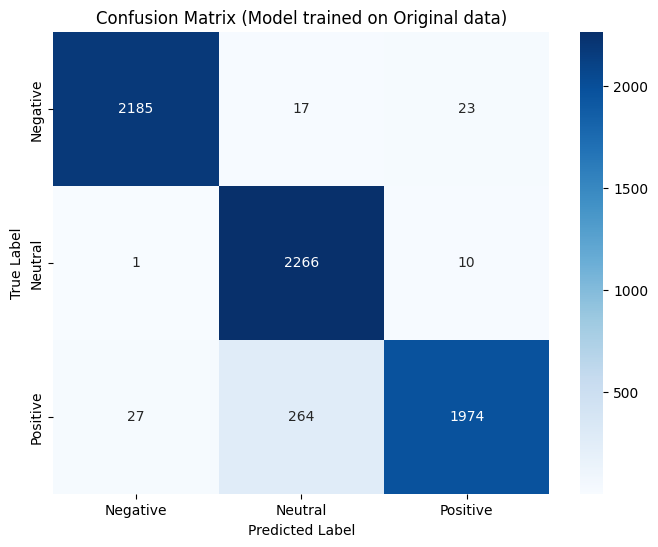

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm_original = [[2185,   17,   23],
 [   1, 2266,   10],
 [  27,  264, 1974]]


plt.figure(figsize=(8, 6))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Model trained on Original data)')
plt.show()

In [ ]:
print("Classification Report:\n",classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      2225
           1       0.92      0.98      0.95      2277
           2       0.98      0.89      0.93      2265

    accuracy                           0.95      6767
   macro avg       0.96      0.95      0.95      6767
weighted avg       0.96      0.95      0.95      6767



In [ ]:
import joblib

# Save the model and TF-IDF vectorizer
joblib.dump(model,'sentiment_model.pkl')  # Save the trained model (Logistic Regression)
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')  # Save the TF-IDF vectorizer

['tfidf_vectorizer.pkl']

In [ ]:
# Load the model and vectorizer
model = joblib.load('sentiment_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

In [ ]:
import re
import string

def review_cleaning(text):

    text = str(text).lower()  # Convert to lowercase
    text = re.sub('\[.*?\]', '', text)  # Remove text in square brackets
    text = re.sub('https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub('<.*?>+', '', text)  # Remove HTML tags
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub('\n', '', text)  # Remove newlines
    text = re.sub('\w*\d\w*', '', text)  # Remove words with numbers
    return text

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in stop_words])
    return ' '.join([word for word in text.split() if word not in stop_words])


    # end , the , a , is

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def perform_stemming(text):
    """
    Apply stemming to a given text using PorterStemmer.
    """
    words = text.split()
    stemmed_words = [ps.stem(word) for word in words]
    return ' '.join(stemmed_words)

    # "He was running and studies were ongoing"
    # He wa run and studi were ongoing

In [ ]:
def preprocess_text(text):
    """
    Full preprocessing pipeline: cleaning, removing stopwords, and stemming.
    """
    text = review_cleaning(text)  # Clean the text
    text = remove_stopwords(text)  # Remove stopwords
    text = perform_stemming(text)  # Apply stemming
    return text

In [ ]:
# Example input text
text = "The product quality is good."

# Preprocess and vectorize the input
preprocessed_text = preprocess_text(text)
input_vectorized = vectorizer.transform([preprocessed_text])  # Convert to TF-IDF features

In [ ]:
# Predict sentiment
prediction = model.predict(input_vectorized)
sentiment_classes = ['Negative', 'Neutral', 'Positive']
predicted_sentiment = sentiment_classes[prediction[0]]

print(f"Predicted Sentiment: {predicted_sentiment}")

Predicted Sentiment: Positive


In [ ]:
# Example input text
text = "The product quality is very bad ."

# Preprocess and vectorize the input
preprocessed_text = preprocess_text(text)
input_vectorized = tfidf_vectorizer.transform([preprocessed_text])   # Use the updated tfidf_vectorizer

In [ ]:
# Predict sentiment
prediction = model.predict(input_vectorized)
sentiment_classes = ['Negative', 'Neutral', 'Positive']
predicted_sentiment = sentiment_classes[prediction[0]]

print(f"Predicted Sentiment: {predicted_sentiment}")

Predicted Sentiment: Negative


In [ ]:
# A list of 20 diverse text examples
example_texts_20 = [
    "This product is absolutely fantastic! Highly recommended.", # Positive
    "It's okay, nothing special. Works as advertised.", # Neutral
    "Very disappointed with the quality. It broke after a week.", # Negative
    "The battery life is excellent, lasts all day.", # Positive
    "The instructions were a bit confusing.", # Neutral/Negative
    "Amazing value for the price, couldn't be happier.", # Positive
    "It's just average, not great, not terrible.", # Neutral
    "Customer service was unhelpful and rude.", # Negative
    "Works perfectly fine for my needs.", # Positive
    "The color is slightly different from the picture.", # Neutral
    "This is the worst product I've ever bought.", # Negative
    "Easy to set up and use.", # Positive
    "The packaging was damaged upon arrival.", # Negative
    "Good quality materials used.", # Positive
    "It's a bit smaller than I expected.", # Neutral
    "I would not recommend this product.", # Negative
    "Very durable and sturdy.", # Positive
    "The sound quality is decent.", # Neutral
    "Experienced some issues with the software.", # Negative
    "Overall, a satisfactory purchase." # Positive/Neutral
]

# Preprocess and predict sentiment for each example
print("Testing with 20 diverse text examples:")
for i, text in enumerate(example_texts_20):
    preprocessed_text = preprocess_text(text)
    input_vectorized = tfidf_vectorizer.transform([preprocessed_text])

    # Predict sentiment
    prediction = model.predict(input_vectorized)
    predicted_sentiment = sentiment_classes[prediction[0]]

    # Predict probabilities
    probabilities = model.predict_proba(input_vectorized)

    print(f"\nExample {i+1}: '{text}'")
    print(f"Predicted Sentiment: {predicted_sentiment}")
    print("Probabilities:")
    for j, sentiment in enumerate(sentiment_classes):
        print(f"  {sentiment}: {probabilities[0][j]:.2f}")

Testing with 20 diverse text examples:

Example 1: 'This product is absolutely fantastic! Highly recommended.'
Predicted Sentiment: Positive
Probabilities:
  Negative: 0.44
  Neutral: 0.02
  Positive: 0.55

Example 2: 'It's okay, nothing special. Works as advertised.'
Predicted Sentiment: Neutral
Probabilities:
  Negative: 0.11
  Neutral: 0.88
  Positive: 0.01

Example 3: 'Very disappointed with the quality. It broke after a week.'
Predicted Sentiment: Negative
Probabilities:
  Negative: 0.94
  Neutral: 0.05
  Positive: 0.00

Example 4: 'The battery life is excellent, lasts all day.'
Predicted Sentiment: Positive
Probabilities:
  Negative: 0.13
  Neutral: 0.18
  Positive: 0.68

Example 5: 'The instructions were a bit confusing.'
Predicted Sentiment: Neutral
Probabilities:
  Negative: 0.02
  Neutral: 0.52
  Positive: 0.46

Example 6: 'Amazing value for the price, couldn't be happier.'
Predicted Sentiment: Positive
Probabilities:
  Negative: 0.01
  Neutral: 0.07
  Positive: 0.91

Example